<a href="https://colab.research.google.com/github/duashah2005/ML_lab/blob/main/lab3/lab3_SyedaDuaShah_churn_dt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

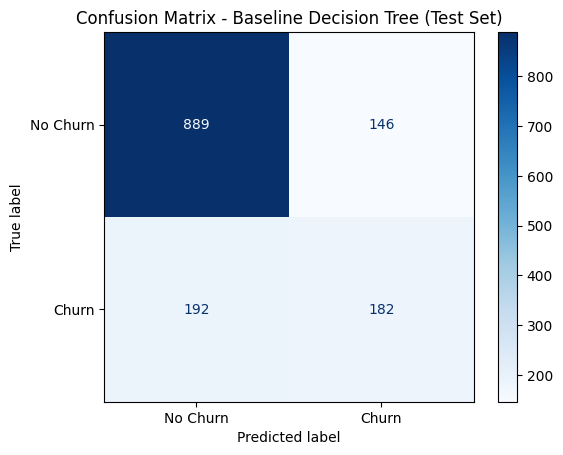

[[889 146]
 [192 182]]
Baseline Train Accuracy: 0.9980475683351083
Baseline Test Accuracy: 0.7601135557132718
Gap: 0.23793401262183655
   max_depth  train_acc  test_acc
0        2.0   0.791090  0.787083
1        3.0   0.791090  0.787083
2        4.0   0.792687  0.795600
3        5.0   0.802627  0.794180
4        6.0   0.811857  0.798439
5        8.0   0.840433  0.784954
6       10.0   0.876997  0.773598
7        NaN   0.998048  0.760114


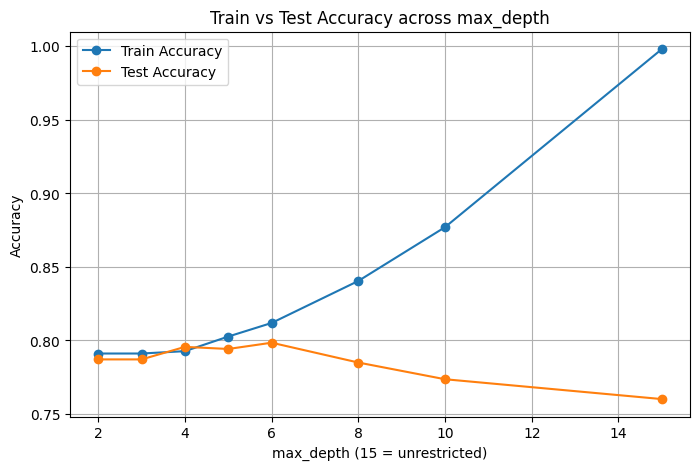

      Metric  Baseline  Chosen Depth (6)
0   Accuracy  0.760114          0.798439
1  Precision  0.554878          0.663043
2     Recall  0.486631          0.489305
3   F1-score  0.518519          0.563077


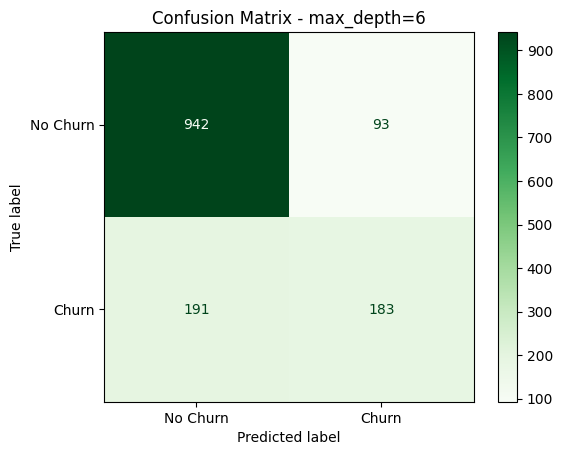

              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.66      0.49      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

      Metric  Gini (depth 6)  Entropy (depth 6)
0   Accuracy        0.798439           0.794890
1  Precision        0.663043           0.610966
2     Recall        0.489305           0.625668
3   F1-score        0.563077           0.618230
tenure                                 0.422940
InternetService_Fiber optic            0.326103
PaymentMethod_Electronic check         0.033146
MonthlyCharges                         0.033005
Contract_Two year                      0.023904
MultipleLines_Yes                      0.021222
StreamingTV_No internet service        0.018851
Contract_One year                      0.016110
StreamingMovies_No internet service    0.015851
T

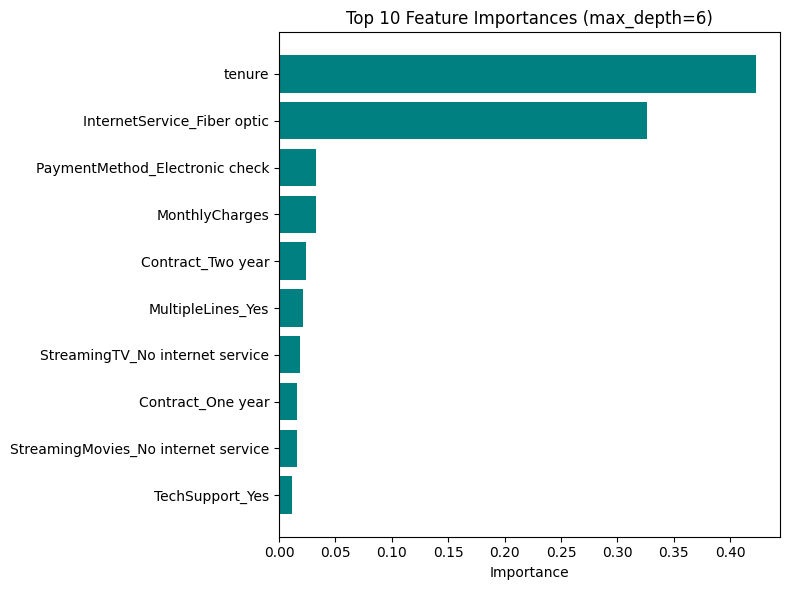


--- Split at depth 0, 14 examples ---
  Gain(Outlook) = 0.2467
  Gain(Temp) = 0.0292
  Gain(Humidity) = 0.1518
  Gain(Wind) = 0.0481
Chosen: Outlook

--- Split at depth 1, 5 examples ---
  Gain(Temp) = 0.5710
  Gain(Humidity) = 0.9710
  Gain(Wind) = 0.0200
Chosen: Humidity

--- Split at depth 1, 5 examples ---
  Gain(Temp) = 0.0200
  Gain(Humidity) = 0.0200
  Gain(Wind) = 0.9710
Chosen: Wind

Final tree:
{'Outlook': {'Sunny': {'Humidity': {'Normal': 'Yes', 'High': 'No'}}, 'Rain': {'Wind': {'Strong': 'No', 'Weak': 'Yes'}}, 'Overcast': 'Yes'}}


In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv('clean_churn_raw.csv')
print(df.shape)
df.info()
df['Churn'].value_counts()

# Task 3 — Define y and X
y = df['Churn'].map({'Yes': 1, 'No': 0}) if df['Churn'].dtype == object else df['Churn']

X = df.drop(columns=['Churn', 'customerID'], errors='ignore')

print(y.value_counts())
print(X.columns.tolist())

cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(X.shape)
print(X.dtypes.value_counts())


print(X.dtypes.unique())
print(X.isnull().sum().sum())


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


from sklearn.tree import DecisionTreeClassifier

baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_train, y_train)

y_train_pred = baseline.predict(X_train)
y_test_pred = baseline.predict(X_test)


depth = baseline.get_depth()
print("Tree depth:", depth)



# Task 10 — Compute metrics on the test set
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
import matplotlib.pyplot as plt
import pandas as pd

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [acc, prec, rec, f1]
})
print(metrics_table)


# Task 11 — Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Baseline Decision Tree (Test Set)')
plt.show()

print(cm)


# Task 13 — Baseline train vs test accuracy
from sklearn.metrics import accuracy_score

train_acc_baseline = accuracy_score(y_train, y_train_pred)
test_acc_baseline = accuracy_score(y_test, y_test_pred)

print("Baseline Train Accuracy:", train_acc_baseline)
print("Baseline Test Accuracy:", test_acc_baseline)
print("Gap:", train_acc_baseline - test_acc_baseline)

# Task 14 — Train multiple trees at different depths
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    results.append({'max_depth': d, 'train_acc': train_acc, 'test_acc': test_acc})

results_df = pd.DataFrame(results)
print(results_df)


# Task 15 — Plot train vs test accuracy across depths
import matplotlib.pyplot as plt

# Replace None with a number for plotting purposes (e.g. max depth + a bit, or 15)
plot_depths = [d if d is not None else 15 for d in depths]

plt.figure(figsize=(8,5))
plt.plot(plot_depths, results_df['train_acc'], marker='o', label='Train Accuracy')
plt.plot(plot_depths, results_df['test_acc'], marker='o', label='Test Accuracy')
plt.xlabel('max_depth (15 = unrestricted)')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy across max_depth')
plt.legend()
plt.grid(True)
plt.show()



chosen_depth = 6


# Task 17 — Retrain at chosen depth, full evaluation
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
import pandas as pd
import matplotlib.pyplot as plt

final_model = DecisionTreeClassifier(max_depth=chosen_depth, random_state=42)
final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

acc_f = accuracy_score(y_test, y_pred_final)
prec_f = precision_score(y_test, y_pred_final)
rec_f = recall_score(y_test, y_pred_final)
f1_f = f1_score(y_test, y_pred_final)

print(pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Baseline': [accuracy_score(y_test, y_test_pred), precision_score(y_test, y_test_pred),
                 recall_score(y_test, y_test_pred), f1_score(y_test, y_test_pred)],
    'Chosen Depth (6)': [acc_f, prec_f, rec_f, f1_f]
}))

cm_final = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm_final, display_labels=['No Churn','Churn']).plot(cmap='Greens')
plt.title(f'Confusion Matrix - max_depth={chosen_depth}')
plt.show()

print(classification_report(y_test, y_pred_final, target_names=['No Churn','Churn']))


# Task 18 — Retrain with entropy criterion at same chosen depth
entropy_model = DecisionTreeClassifier(max_depth=chosen_depth, criterion='entropy', random_state=42)
entropy_model.fit(X_train, y_train)
y_pred_entropy = entropy_model.predict(X_test)

acc_e = accuracy_score(y_test, y_pred_entropy)
prec_e = precision_score(y_test, y_pred_entropy)
rec_e = recall_score(y_test, y_pred_entropy)
f1_e = f1_score(y_test, y_pred_entropy)

print(pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Gini (depth 6)': [acc_f, prec_f, rec_f, f1_f],
    'Entropy (depth 6)': [acc_e, prec_e, rec_e, f1_e]
}))

# Task 19 — Feature importances
importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

plt.figure(figsize=(8,6))
top10 = importances.head(10)
plt.barh(top10.index[::-1], top10.values[::-1], color='teal')
plt.xlabel('Importance')
plt.title(f'Top 10 Feature Importances (max_depth={chosen_depth})')
plt.tight_layout()
plt.show()


import math
from collections import Counter

# Play Badminton dataset (classic example — replace with your class's exact table if different)
data = [
    {'Outlook':'Sunny','Temp':'Hot','Humidity':'High','Wind':'Weak','Play':'No'},
    {'Outlook':'Sunny','Temp':'Hot','Humidity':'High','Wind':'Strong','Play':'No'},
    {'Outlook':'Overcast','Temp':'Hot','Humidity':'High','Wind':'Weak','Play':'Yes'},
    {'Outlook':'Rain','Temp':'Mild','Humidity':'High','Wind':'Weak','Play':'Yes'},
    {'Outlook':'Rain','Temp':'Cool','Humidity':'Normal','Wind':'Weak','Play':'Yes'},
    {'Outlook':'Rain','Temp':'Cool','Humidity':'Normal','Wind':'Strong','Play':'No'},
    {'Outlook':'Overcast','Temp':'Cool','Humidity':'Normal','Wind':'Strong','Play':'Yes'},
    {'Outlook':'Sunny','Temp':'Mild','Humidity':'High','Wind':'Weak','Play':'No'},
    {'Outlook':'Sunny','Temp':'Cool','Humidity':'Normal','Wind':'Weak','Play':'Yes'},
    {'Outlook':'Rain','Temp':'Mild','Humidity':'Normal','Wind':'Weak','Play':'Yes'},
    {'Outlook':'Sunny','Temp':'Mild','Humidity':'Normal','Wind':'Strong','Play':'Yes'},
    {'Outlook':'Overcast','Temp':'Mild','Humidity':'High','Wind':'Strong','Play':'Yes'},
    {'Outlook':'Overcast','Temp':'Hot','Humidity':'Normal','Wind':'Weak','Play':'Yes'},
    {'Outlook':'Rain','Temp':'Mild','Humidity':'High','Wind':'Strong','Play':'No'},
]

def entropy(rows, target='Play'):
    counts = Counter(r[target] for r in rows)
    total = len(rows)
    return -sum((c/total) * math.log2(c/total) for c in counts.values())

def info_gain(rows, attr, target='Play'):
    total_entropy = entropy(rows, target)
    total = len(rows)
    values = set(r[attr] for r in rows)
    weighted = 0
    for v in values:
        subset = [r for r in rows if r[attr] == v]
        weighted += (len(subset)/total) * entropy(subset, target)
    return total_entropy - weighted

def best_attribute(rows, attrs, target='Play'):
    gains = {a: info_gain(rows, a, target) for a in attrs}
    for a, g in gains.items():
        print(f"  Gain({a}) = {g:.4f}")
    return max(gains, key=gains.get)

def id3(rows, attrs, target='Play', depth=0):
    labels = [r[target] for r in rows]
    if labels.count(labels[0]) == len(labels):
        return labels[0]
    if not attrs:
        return Counter(labels).most_common(1)[0][0]

    print(f"\n--- Split at depth {depth}, {len(rows)} examples ---")
    best = best_attribute(rows, attrs, target)
    print(f"Chosen: {best}")

    tree = {best: {}}
    remaining = [a for a in attrs if a != best]
    for v in set(r[best] for r in rows):
        subset = [r for r in rows if r[best] == v]
        if not subset:
            tree[best][v] = Counter(labels).most_common(1)[0][0]
        else:
            tree[best][v] = id3(subset, remaining, target, depth+1)
    return tree

attributes = ['Outlook','Temp','Humidity','Wind']
tree = id3(data, attributes)
print("\nFinal tree:")
print(tree)